# Phase 2: induced velocity $v_i$, advance ratio $\mu$, shaft AoA $\alpha_s$
Simple first look: distributions across the whole dataset.

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import utils

d = utils.load_bem()
vi, mu, als = utils.diagnostics(d)
als_deg = np.degrees(als)
print(d.shape[0], 'rows')

1798481 rows


In [15]:
for name, x, unit in [('v_i', vi, 'm/s'), ('mu', mu, '-'), ('alpha_s', als_deg, 'deg')]:
    p = np.percentile(x, [0, 5, 50, 95, 100])
    print(f'{name:8s}[{unit}]  min={p[0]:8.3f}  p5={p[1]:8.3f}  med={p[2]:8.3f}  p95={p[3]:8.3f}  max={p[4]:8.3f}')

v_i     [m/s]  min=  -0.040  p5=   6.169  med=   8.031  p95=  13.867  max=  24.909
mu      [-]  min=   0.000  p5=   0.000  med=   0.035  p95=   0.102  max=   0.612
alpha_s [deg]  min= -89.997  p5= -59.462  med=  -4.804  p95=  86.628  max=  89.997


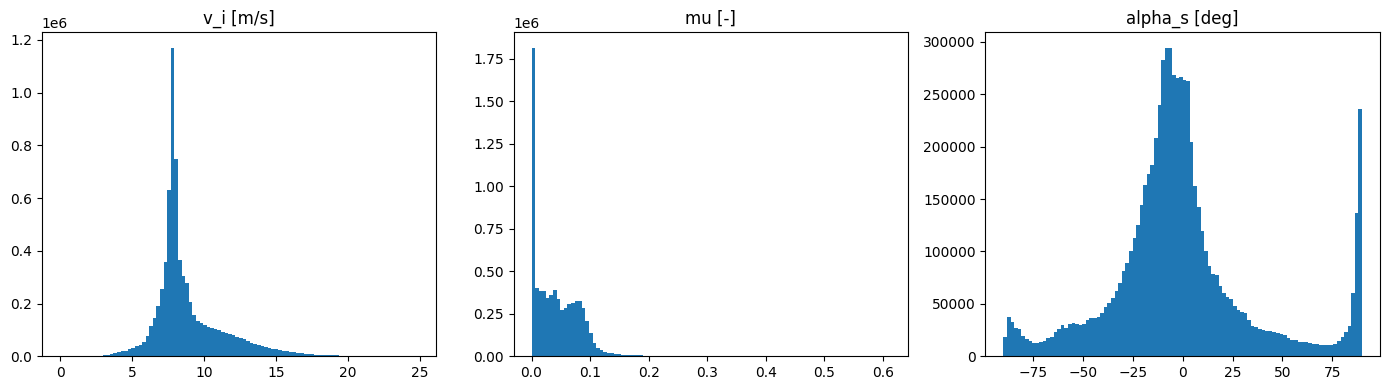

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].hist(vi.ravel(), bins=100); ax[0].set_title('v_i [m/s]')
ax[1].hist(mu.ravel(), bins=100); ax[1].set_title('mu [-]')
ax[2].hist(als_deg.ravel(), bins=100); ax[2].set_title('alpha_s [deg]')
plt.tight_layout(); plt.show()

## Where does the error live?  (inflow vs coefficients)

In [17]:
ferr, terr = utils.residuals(d)
fmeas, _ = utils.measured(d)
omg = d[:, [20, 21, 22, 23]]

# vortex-ring state: 0 < v_axial / v_i < 2   (paper eq. 18)
v_axial = mu * omg * utils.R * np.tan(als)
ratio = v_axial / np.maximum(vi, 1e-6)
vrs = (ratio > 0) & (ratio < 2)
print(f'vortex-ring: {100*vrs.mean():.2f}% of motor-samples, {100*vrs.any(1).mean():.2f}% of rows')

vortex-ring: 40.09% of motor-samples, 45.48% of rows


In [18]:
vi_m, mu_m = vi.mean(1), mu.mean(1)
print('corr |Fz err| vs v_i:', round(np.corrcoef(np.abs(ferr[:, 2]), vi_m)[0, 1], 3))
print('corr |Fz err| vs mu :', round(np.corrcoef(np.abs(ferr[:, 2]), mu_m)[0, 1], 3))

corr |Fz err| vs v_i: 0.488
corr |Fz err| vs mu : 0.494


In [19]:
def binned(regime, edges, label):
    print(f'{label:>12} {"n":>9}   Fx    Fy    Fz     |M|')
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (regime >= lo) & (regime < hi)
        if m.sum() == 0:
            continue
        rf = np.sqrt((ferr[m] ** 2).mean(0))
        rm = np.sqrt((terr[m] ** 2).mean())
        print(f'[{lo:6.3f},{hi:6.3f}) {m.sum():9d}   {rf[0]:.3f} {rf[1]:.3f} {rf[2]:.3f}  {rm:.4f}')

binned(mu_m, [0, 0.02, 0.05, 0.1, 0.2, 10], 'mu')
print()
binned(vi_m, np.percentile(vi_m, [0, 25, 50, 75, 90, 100]), 'v_i')

          mu         n   Fx    Fy    Fz     |M|
[ 0.000, 0.020)    675599   0.174 0.131 0.810  0.0201
[ 0.020, 0.050)    433724   0.421 0.307 1.491  0.0603
[ 0.050, 0.100)    598965   0.703 0.589 2.163  0.1398
[ 0.100, 0.200)     86788   1.081 0.954 2.862  0.1594
[ 0.200,10.000)      3405   2.614 1.420 6.698  0.2026

         v_i         n   Fx    Fy    Fz     |M|
[ 2.052, 7.656)    449620   0.503 0.439 1.388  0.0504
[ 7.656, 8.017)    449620   0.179 0.164 0.667  0.0296
[ 8.017, 9.634)    449620   0.409 0.352 1.189  0.0703
[ 9.634,12.190)    269772   0.808 0.619 2.178  0.1464
[12.190,21.426)    179848   0.876 0.700 3.410  0.1880


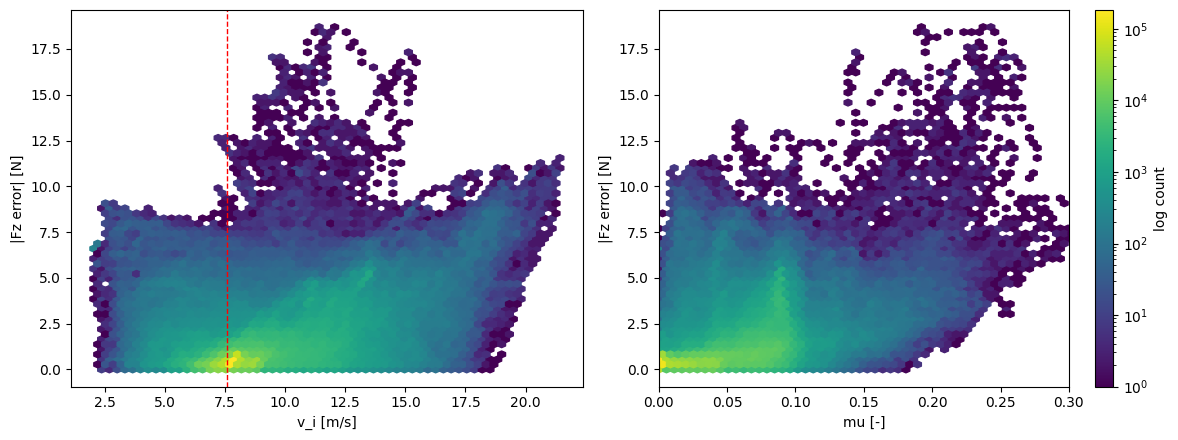

In [20]:
# |Fz error| vs regime (hexbin = density; too many points for a scatter)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
afz = np.abs(ferr[:, 2])
h0 = ax[0].hexbin(vi_m, afz, gridsize=60, bins='log', mincnt=1)
ax[0].set_xlabel('v_i [m/s]'); ax[0].set_ylabel('|Fz error| [N]'); ax[0].axvline(7.6, color='r', ls='--', lw=1)
h1 = ax[1].hexbin(mu_m, afz, gridsize=60, bins='log', mincnt=1)
ax[1].set_xlabel('mu [-]'); ax[1].set_ylabel('|Fz error| [N]'); ax[1].set_xlim(0, 0.3)
fig.colorbar(h1, ax=ax[1], label='log count')
plt.tight_layout(); plt.show()

## Decision: is the vortex-ring branch to blame?
Compare error inside vs outside vortex-ring. `rel` = RMSE / mean|measured force| removes the
"bigger forces just have bigger errors" confound. If `rel` is similar in/out -> coefficients;
if much worse inside VRS -> the empirical inflow branch is a real culprit.

In [21]:
row = vrs.any(1)
print(f'{"group":>12} {"n":>9}   Fx    Fy    Fz     rel(Fz)')
for lbl, m in [('vortex-ring', row), ('normal', ~row)]:
    rf = np.sqrt((ferr[m] ** 2).mean(0))
    rel = rf[2] / np.abs(fmeas[m, 2]).mean()
    print(f'{lbl:>12} {m.sum():9d}   {rf[0]:.3f} {rf[1]:.3f} {rf[2]:.3f}   {rel:.3f}')

       group         n   Fx    Fy    Fz     rel(Fz)
 vortex-ring    817954   0.497 0.379 1.824   0.177
      normal    980527   0.567 0.483 1.549   0.126
